# M1: trained scDiffEq baseline
The real LARRY 1500-epoch run completed; this notebook restores its checkpoint and displays measured outputs rather than retraining on every execution. Reproduce training with `python -m src.baseline` (smoke stage first). Source: https://www.scdiffeq.com/_tutorials/quickstart.html

In [1]:
from pathlib import Path
import os,sys,json
ROOT=Path.cwd()
if ROOT.name=='notebooks':ROOT=ROOT.parent
os.chdir(ROOT);sys.path.insert(0,str(ROOT))


In [2]:
run=json.loads(Path('outputs/baseline/official/runtime.json').read_text())
{k:run[k] for k in ('seed','epochs','seconds','peak_cuda_bytes','simulation_shape','same_seed_simulation_verified')}

{'seed': 0,
 'epochs': 1500,
 'seconds': 1784.0680017800187,
 'peak_cuda_bytes': 2422240256,
 'simulation_shape': [1968, 50],
 'same_seed_simulation_verified': True}

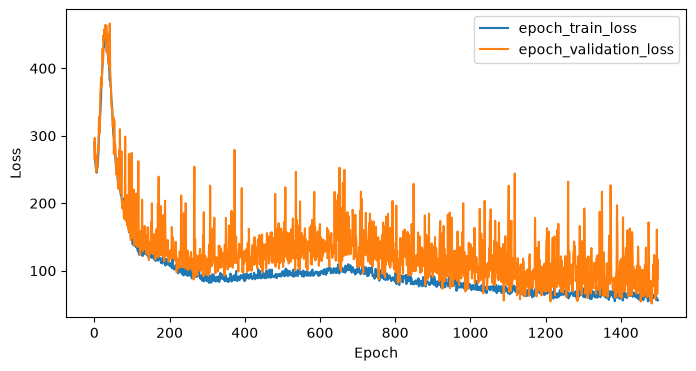

In [3]:
import pandas as pd,matplotlib.pyplot as plt
metrics=pd.read_csv('outputs/baseline/official/metrics_export.csv')
fig,ax=plt.subplots(figsize=(8,4))
for key in ('epoch_train_loss','epoch_validation_loss'):
    clean=metrics[['epoch',key]].dropna();ax.plot(clean.epoch,clean[key],label=key)
ax.set(xlabel='Epoch',ylabel='Loss');ax.legend();plt.show()

In [4]:
from src.teacher import TeacherSDE,simulate_sde
import numpy as np
teacher=TeacherSDE(Path('outputs/baseline/official/teacher.ckpt'))
x=np.load('outputs/distillation/observed_states.npy')[:8]
f,g=teacher.evaluate(x)
print('f:',f.shape,'G:',g.shape,'finite:',np.isfinite(f).all() and np.isfinite(g).all())
print(json.loads(Path('outputs/baseline/official/split_audit.json').read_text()))

f: (8, 50) G: (8, 50, 1) finite: True
{'train_validation_clone_overlap': 292, 'interpretation': 'Official cell-level reproduction; not an independent clone-held-out biological evaluation.'}


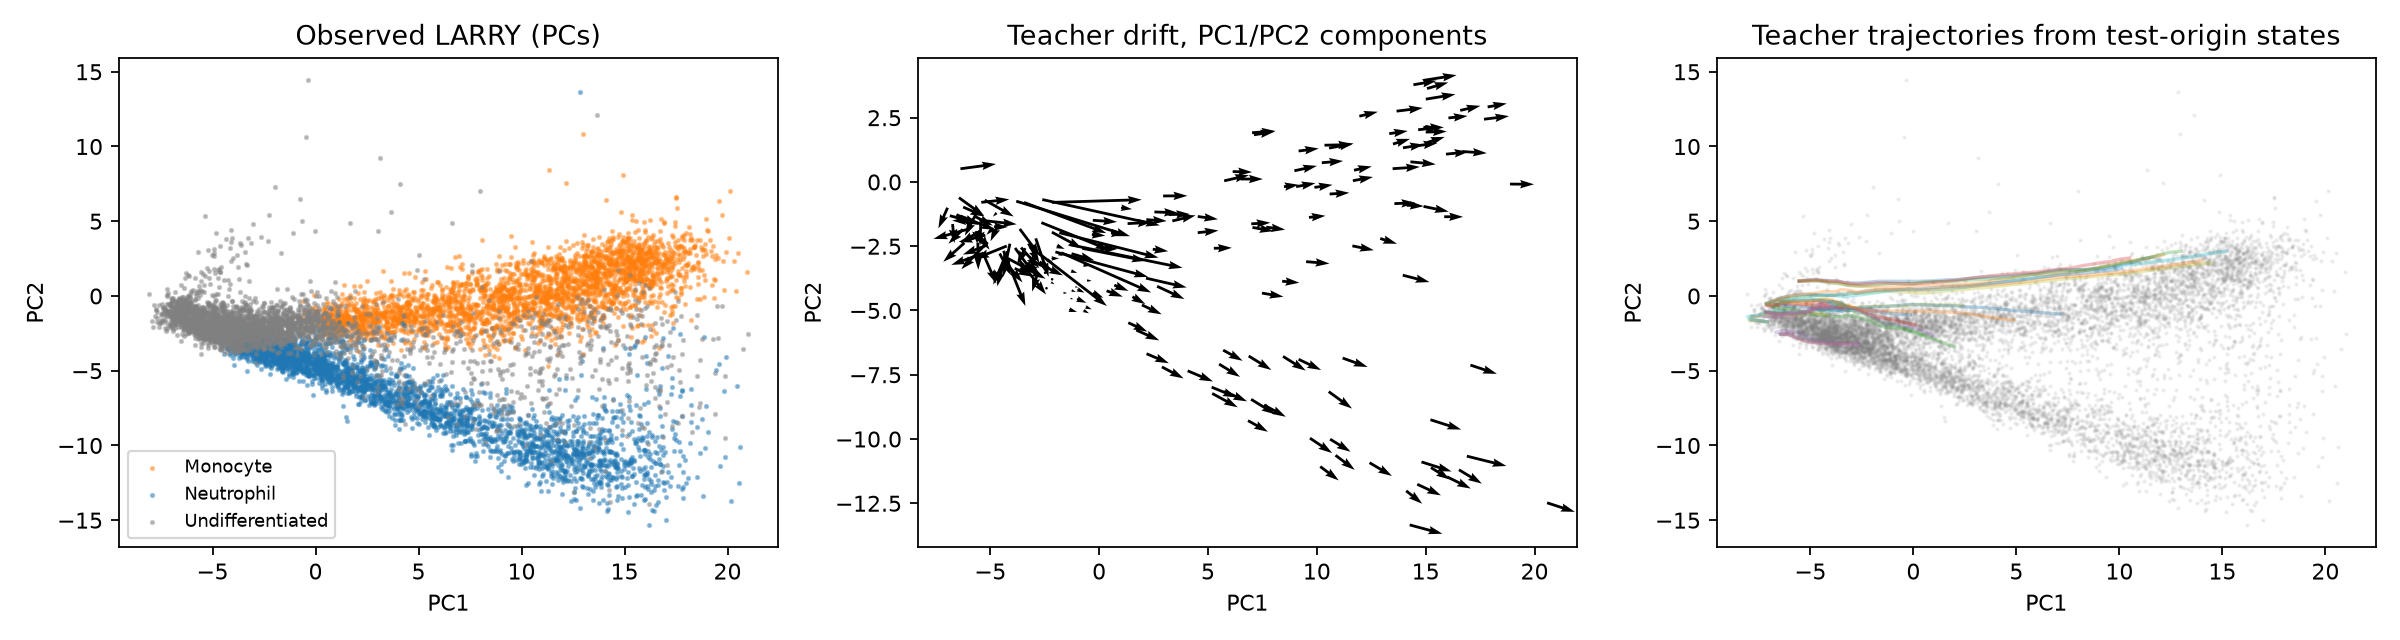

,time,source,fate,fraction
0,2.0,Observed data,Monocyte,0.000000
1,2.0,Observed data,Neutrophil,0.000000
2,2.0,Observed data,Undifferentiated,1.000000
3,2.0,Neural SDE teacher,Monocyte,0.000000
4,2.0,Neural SDE teacher,Neutrophil,0.000000
5,2.0,Neural SDE teacher,Undifferentiated,1.000000
6,4.0,Observed data,Monocyte,0.178512
7,4.0,Observed data,Neutrophil,0.219835
8,4.0,Observed data,Undifferentiated,0.601653
9,4.0,Neural SDE teacher,Monocyte,0.335938


In [5]:
from IPython.display import Image,display
display(Image(filename='outputs/figures/teacher_baseline.png'))
display(pd.read_csv('outputs/tables/teacher_observed_fates.csv'))

Qualitative inspection: teacher drift points into the two class-associated branches in the PC1/PC2 projection. Trajectories leave the undifferentiated region and populate both branches. This is qualitatively compatible with the official branching example, but layout/initial cells/versions differ. Neutrophil fraction at day 6 is ~0.21 versus ~0.36 in the observed distillation-test partition for this small initial sample. Do not equate this figure with quantitative correctness. Cell-level teacher train/validation share 292 clones; new symbolic partitions are clone-disjoint but teacher exposure remains.